In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

from otter import Otter
import syncfit


In [2]:
wise_phot = pd.read_csv("data/wise-photometry.csv", index_col=0)
radio_phot = pd.read_csv("ecle-photometry.csv")
meta = pd.read_csv("ecle-metadata.csv")

wise_phot["date"] = wise_phot["date_mjd"]
wise_phot["date_format"] = "mjd"
wise_phot["filter_eff_units"] = wise_phot["filter_eff_unit"]

In [3]:
otterpath = "private_otter_data"
overwrite = False

if overwrite:
    if os.path.exists(otterpath):
        for file in glob.glob(os.path.join(otterpath, "*")):
            os.remove(file)
        os.rmdir(otterpath)


    private_data = Otter.from_csvs("ecle-metadata.csv", photfile="all-photometry.csv", local_outpath=otterpath)
else:
    private_data = Otter(datadir=otterpath)

In [4]:
radio = private_data.get_phot(
    names=meta.name.to_list(), 
    obs_type="radio", 
    query_private=True, 
    return_type="pandas",
    flux_unit="mJy",
    freq_unit="GHz"
)

/home/nfranz/astro-otter/otter/src/otter/io/transient.py:845: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because Cannot set a DataFrame with multiple columns to the single column human_readable_refs
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/nfranz/astro-otter/otter/src/otter/io/transient.py:632: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapp

/home/nfranz/astro-otter/otter/src/otter/io/transient.py:845: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(


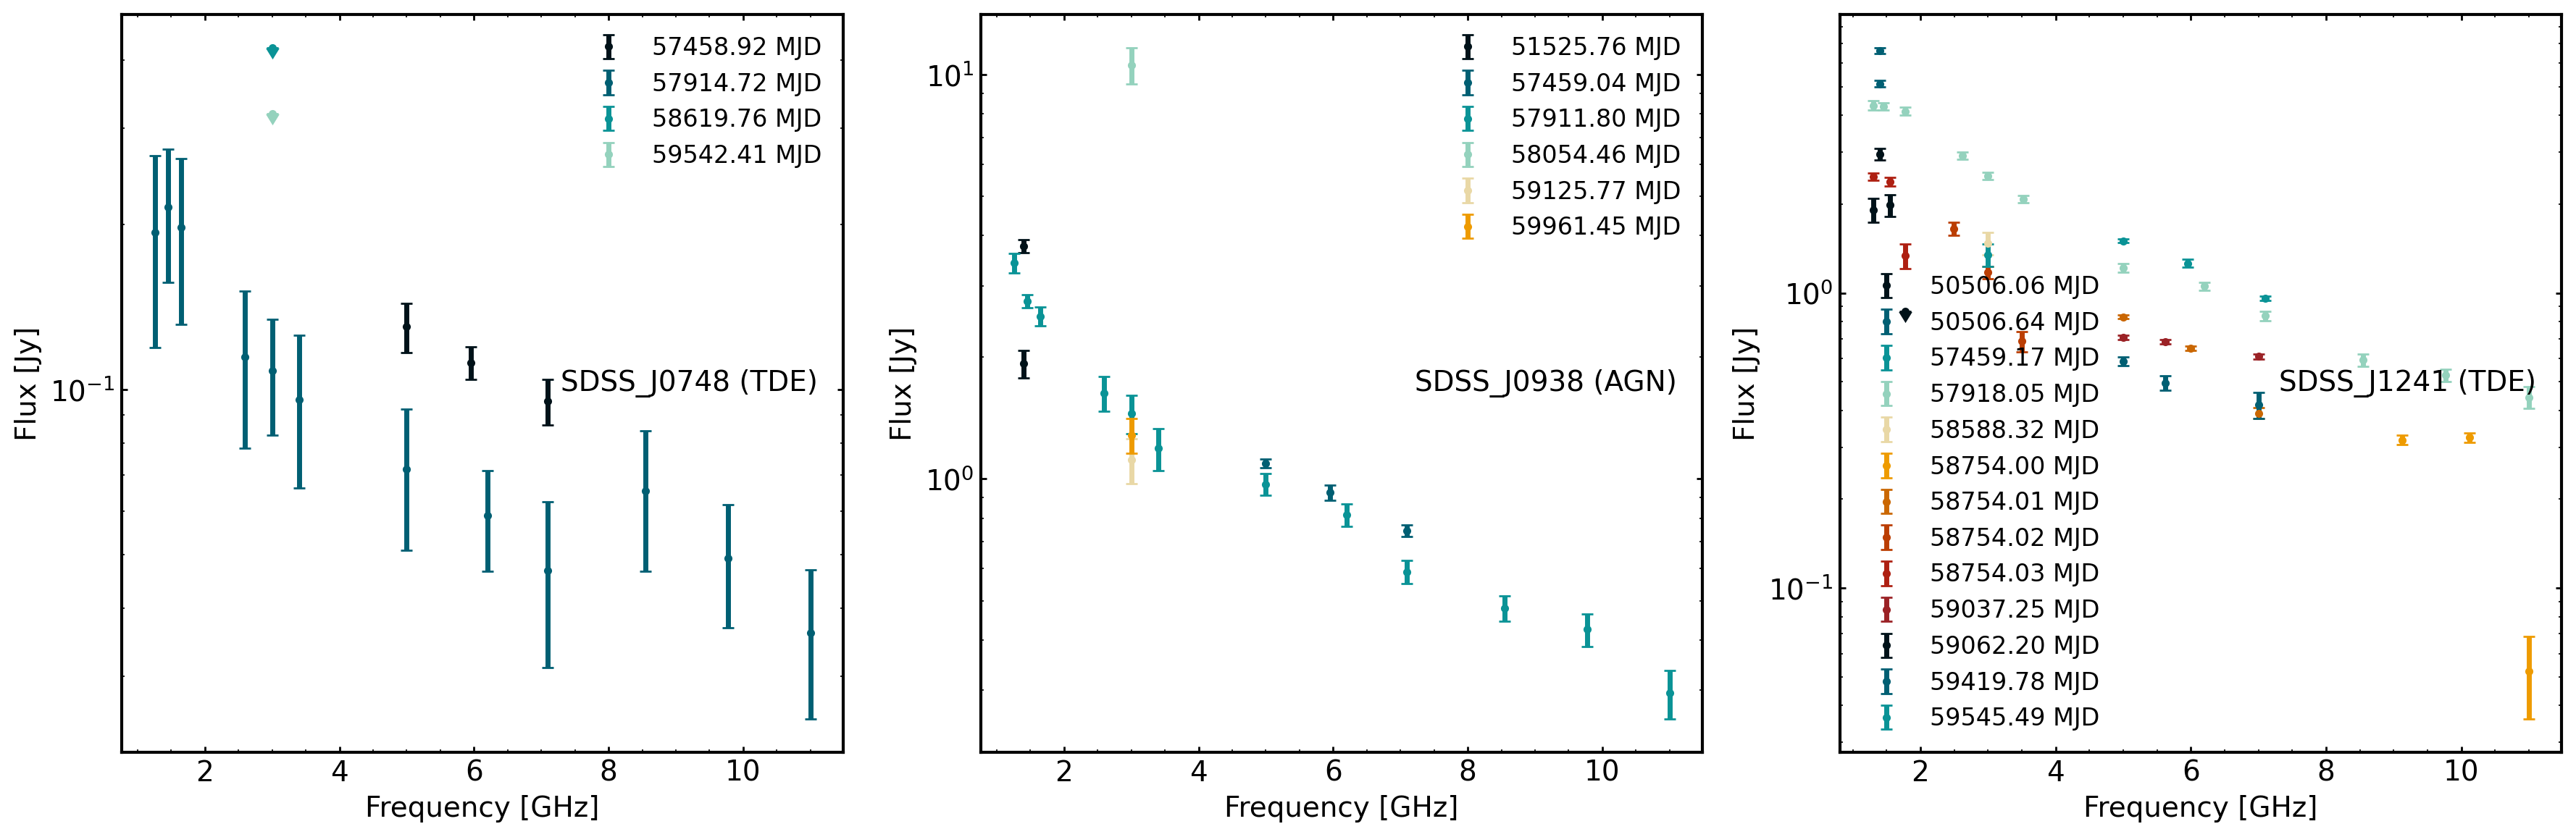

In [5]:
def make_sed(tde_name, ax):
    classes = private_data.query(names=tde_name, query_private=True)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']

    df = radio[radio.name == tde_name]

    for label, grp in df.groupby('converted_date'):

        ax.errorbar(
            grp.converted_freq, 
            grp.converted_flux,
            fmt='o',
            markersize=3,
            yerr=grp.converted_flux_err,
            label=f'{label:.2f} MJD',
            uplims=grp.upperlimit
        )

        # next(ax._get_lines.prop_cycler)['color']


    ax.set_ylabel('Flux [Jy]')
    ax.set_xlabel('Frequency [GHz]')
    ax.set_yscale('log')

    at = AnchoredText(f'{tde_name} ({ecle_class})', 'center right', frameon=False)
    ax.add_artist(at)

    ax.legend(fontsize=12)
    
    return df
    
ecles_with_good_seds = ['SDSS_J0748','SDSS_J0938','SDSS_J1241']
fig, axs = plt.subplots(1,len(ecles_with_good_seds), figsize=(18,6))
                        
for ii, tde_name in enumerate(ecles_with_good_seds):
    make_sed(tde_name, axs[ii])

fig.savefig("good-radio-seds.png")

# SDSS J1241

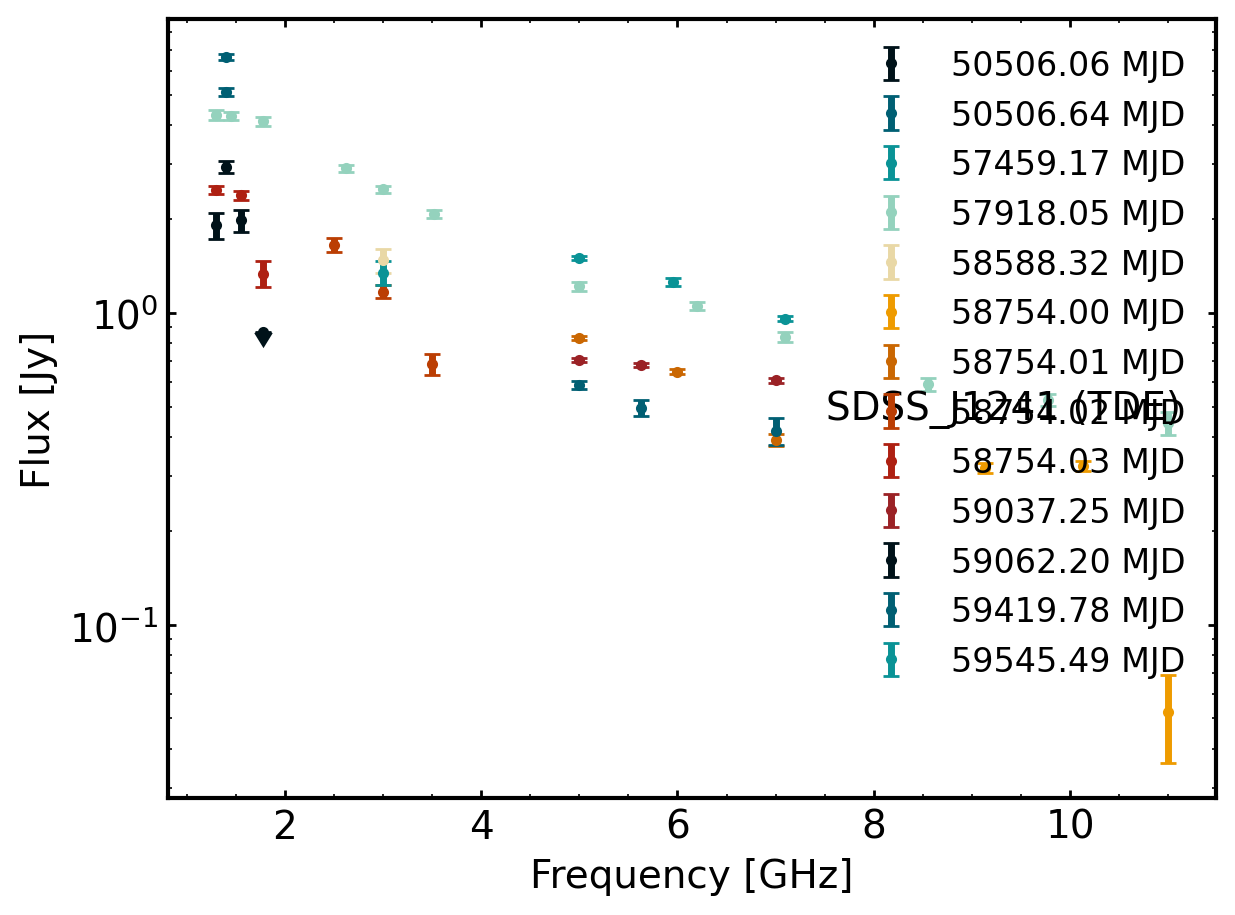

In [6]:
fig, ax = plt.subplots()
df = make_sed("SDSS_J1241", ax=ax)

16426it [00:37, 443.58it/s, batch: 8 | bound: 8 | nc: 1 | ncall: 82230 | eff(%): 19.493 | loglstar: -5.654 < -0.816 < -1.421 | logz: -10.865 +/-  0.077 | stop:  0.909]                  
18163it [00:24, 731.66it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 55247 | eff(%): 32.778 | loglstar: -12.570 < -7.592 < -8.553 | logz: -21.582 +/-  0.095 | stop:  0.896]                   
18076it [00:27, 655.12it/s, batch: 7 | bound: 6 | nc: 1 | ncall: 55302 | eff(%): 32.504 | loglstar: -209.058 < -203.786 < -204.305 | logz: -218.383 +/-  0.103 | stop:  0.926]           
0it [00:13, ?it/s]
15039it [00:31, 480.20it/s, batch: 7 | bound: 11 | nc: 1 | ncall: 67212 | eff(%): 22.160 | loglstar: -6.227 < -1.217 < -1.474 | logz: -10.018 +/-  0.079 | stop:  0.962]                


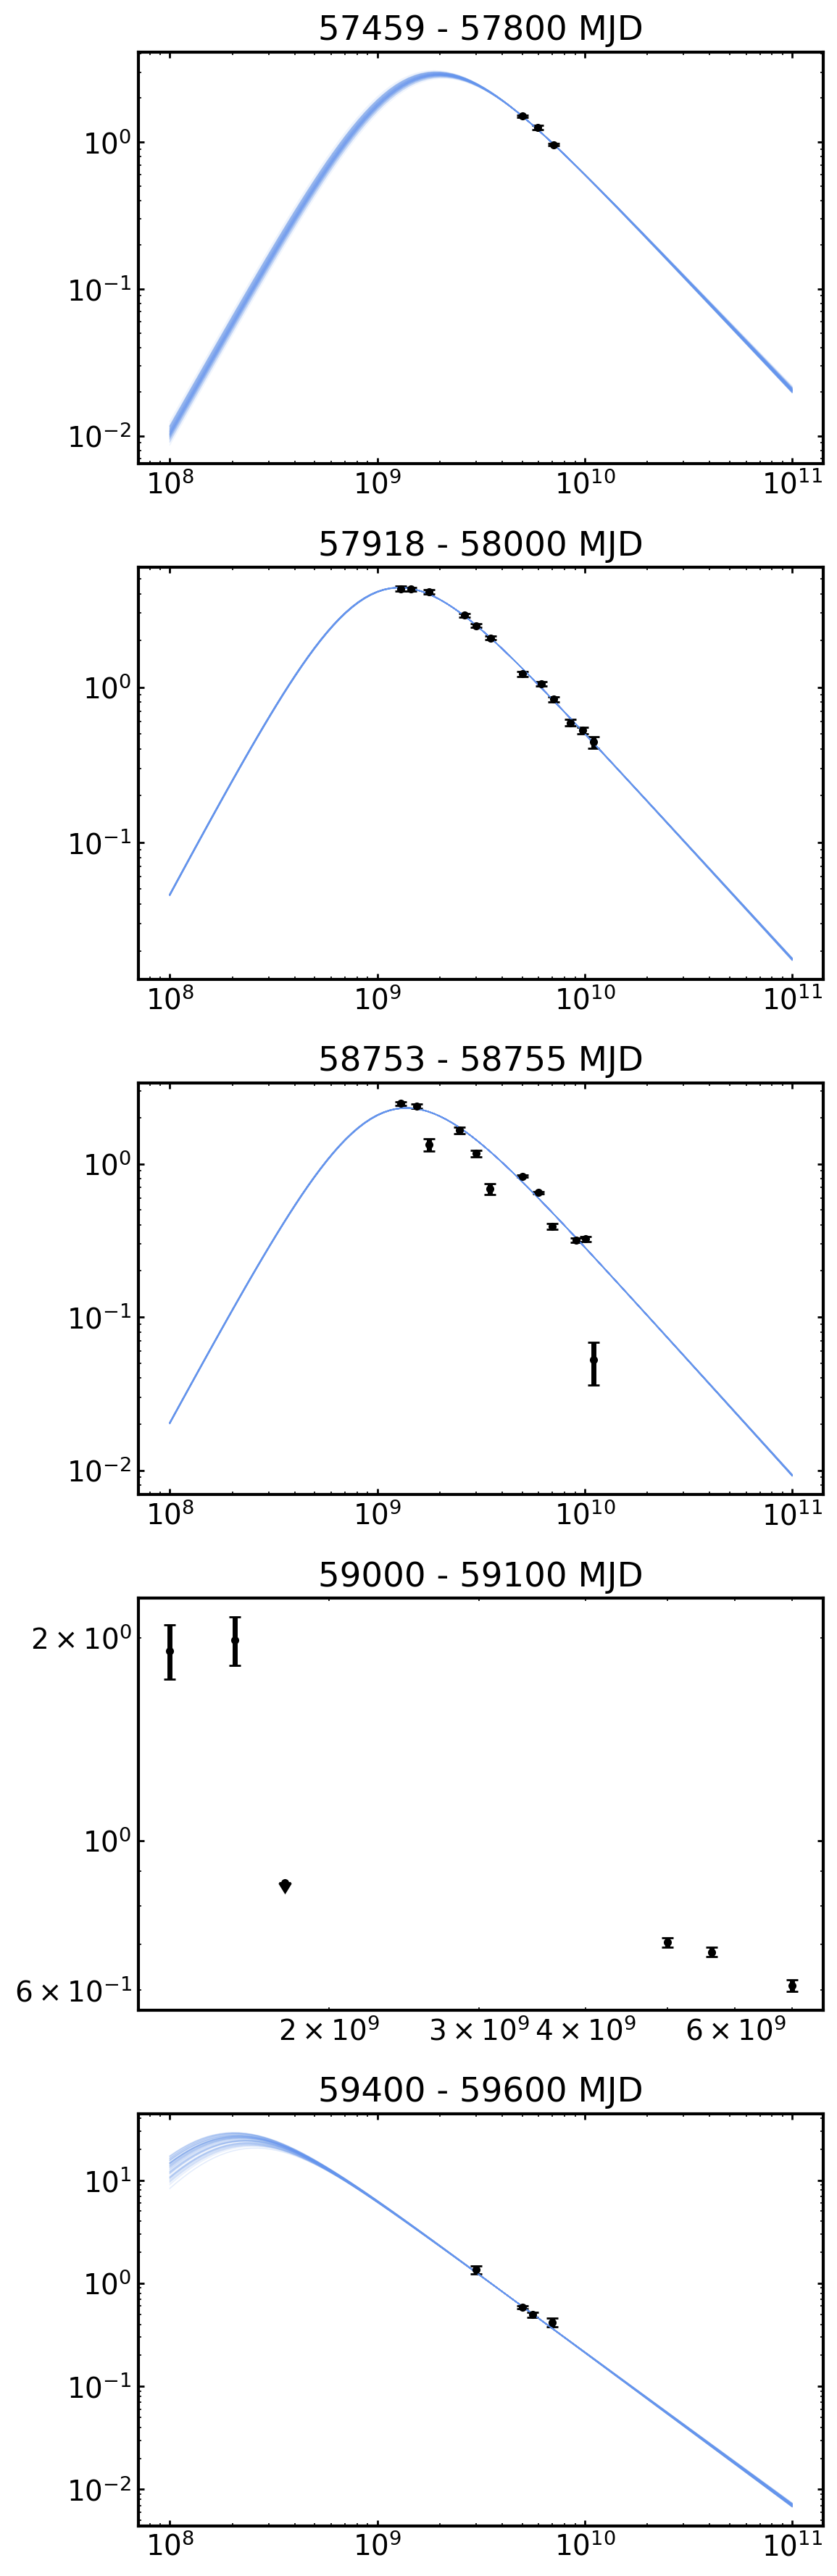

In [33]:
date_ranges = [
    # (50506, 50507),
    (57459, 57800), 
    (57918, 58000),
    # (58580, 58590),
    (58753, 58755),
    (59000, 59100),
    (59400, 59600)
]

nkeep = 100

results = []

fig, axs = plt.subplots(5,1, figsize=(6,18))
for r, ax in zip(date_ranges, axs):
    data = df[(df.converted_date > r[0]) * (df.converted_date < r[1])]
    ax.errorbar(
        data.converted_freq*1e9, 
        data.converted_flux,
        fmt='o',
        markersize=3,
        yerr=data.converted_flux_err,
        label=f'{r[0]} - {r[1]} MJD',
        uplims=data.upperlimit,
        color='k'
    )
    
    ax.set_yscale("log")
    ax.set_xscale("log")

    # ax.legend();
    ax.set_title(f'{r[0]} - {r[1]} MJD')
    
    try:
        model, sampler = syncfit.do_dynesty(
            F_mJy = data.converted_flux,
            F_error=data.converted_flux_err,
            nu=data.converted_freq,
            model=syncfit.models.B5,
            upperlimits=data.upperlimit
        )
    except RuntimeError:
        continue # this means it couldn't fit it...
    
    results.append((model, sampler))
    
    flat_samples, log_prob = syncfit.analysis.util.extract_output(sampler)

    nkeep = 100
    toplot = flat_samples[-nkeep:]
    nu_plot = np.logspace(8,11,100)
    for val in toplot:
        packed_theta = model.pack_theta(val)
        res = model.SED(nu_plot, **packed_theta)

        ax.plot(nu_plot, res,
                '-', color='cornflowerblue', lw = 0.5, alpha = 0.1)
        
        
fig.savefig("SDSSJ1241-radio-fits.png")

# SDSSJ0748

/home/nfranz/astro-otter/otter/src/otter/io/transient.py:845: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(


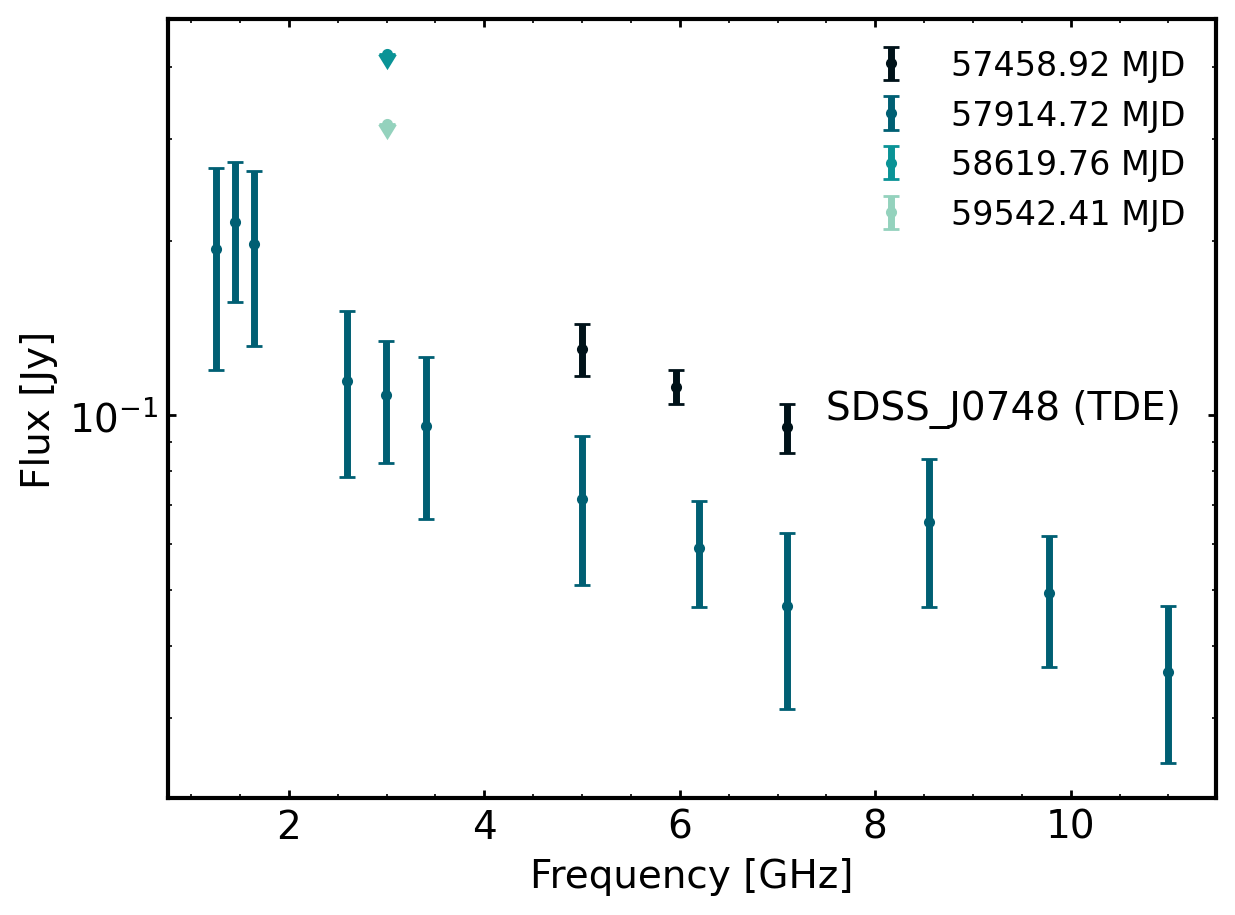

In [35]:
fig, ax = plt.subplots()
df = make_sed("SDSS_J0748", ax=ax)

         name  converted_flux  converted_flux_err  converted_date  \
0  SDSS_J0748          0.1303              0.0135      57458.9162   
2  SDSS_J0748          0.0954              0.0092      57458.9162   
4  SDSS_J0748          0.1121              0.0075      57458.9162   

   converted_wave  converted_freq converted_flux_unit converted_date_unit  \
0    5.997049e+07           4.999                 mJy                 MJD   
2    4.223024e+07           7.099                 mJy                 MJD   
4    5.032608e+07           5.957                 mJy                 MJD   

  converted_wave_unit converted_freq_unit filter_name obs_type upperlimit  \
0                  nm                 GHz           C    radio      False   
2                  nm                 GHz           C    radio      False   
4                  nm                 GHz           C    radio      False   

  reference human_readable_refs telescope  
0   private             private       NaN  
2   private      

14223it [00:55, 254.35it/s, batch: 9 | bound: 15 | nc: 1 | ncall: 113844 | eff(%): 12.379 | loglstar: -4.958 < -0.000 < -0.178 | logz: -5.549 +/-  0.055 | stop:  0.955]            

          name  converted_flux  converted_flux_err  converted_date  \
1   SDSS_J0748          0.0716              0.0206     57914.71674   
3   SDSS_J0748          0.0468              0.0157     57914.71674   
5   SDSS_J0748          0.1934              0.0739     57914.71674   
6   SDSS_J0748          0.1977              0.0661     57914.71674   
7   SDSS_J0748          0.2156              0.0588     57914.71674   
8   SDSS_J0748          0.1148              0.0366     57914.71674   
9   SDSS_J0748          0.0960              0.0299     57914.71674   
10  SDSS_J0748          0.1085              0.0258     57914.71674   
11  SDSS_J0748          0.0589              0.0122     57914.71674   
12  SDSS_J0748          0.0654              0.0187     57914.71674   
13  SDSS_J0748          0.0360              0.0109     57914.71674   
14  SDSS_J0748          0.0493              0.0125     57914.71674   

    converted_wave  converted_freq converted_flux_unit converted_date_unit  \
1     5.997


14654it [00:28, 521.80it/s, batch: 8 | bound: 8 | nc: 1 | ncall: 65400 | eff(%): 21.978 | loglstar: -6.236 < -0.991 < -1.314 | logz: -7.015 +/-  0.058 | stop:  0.900]            


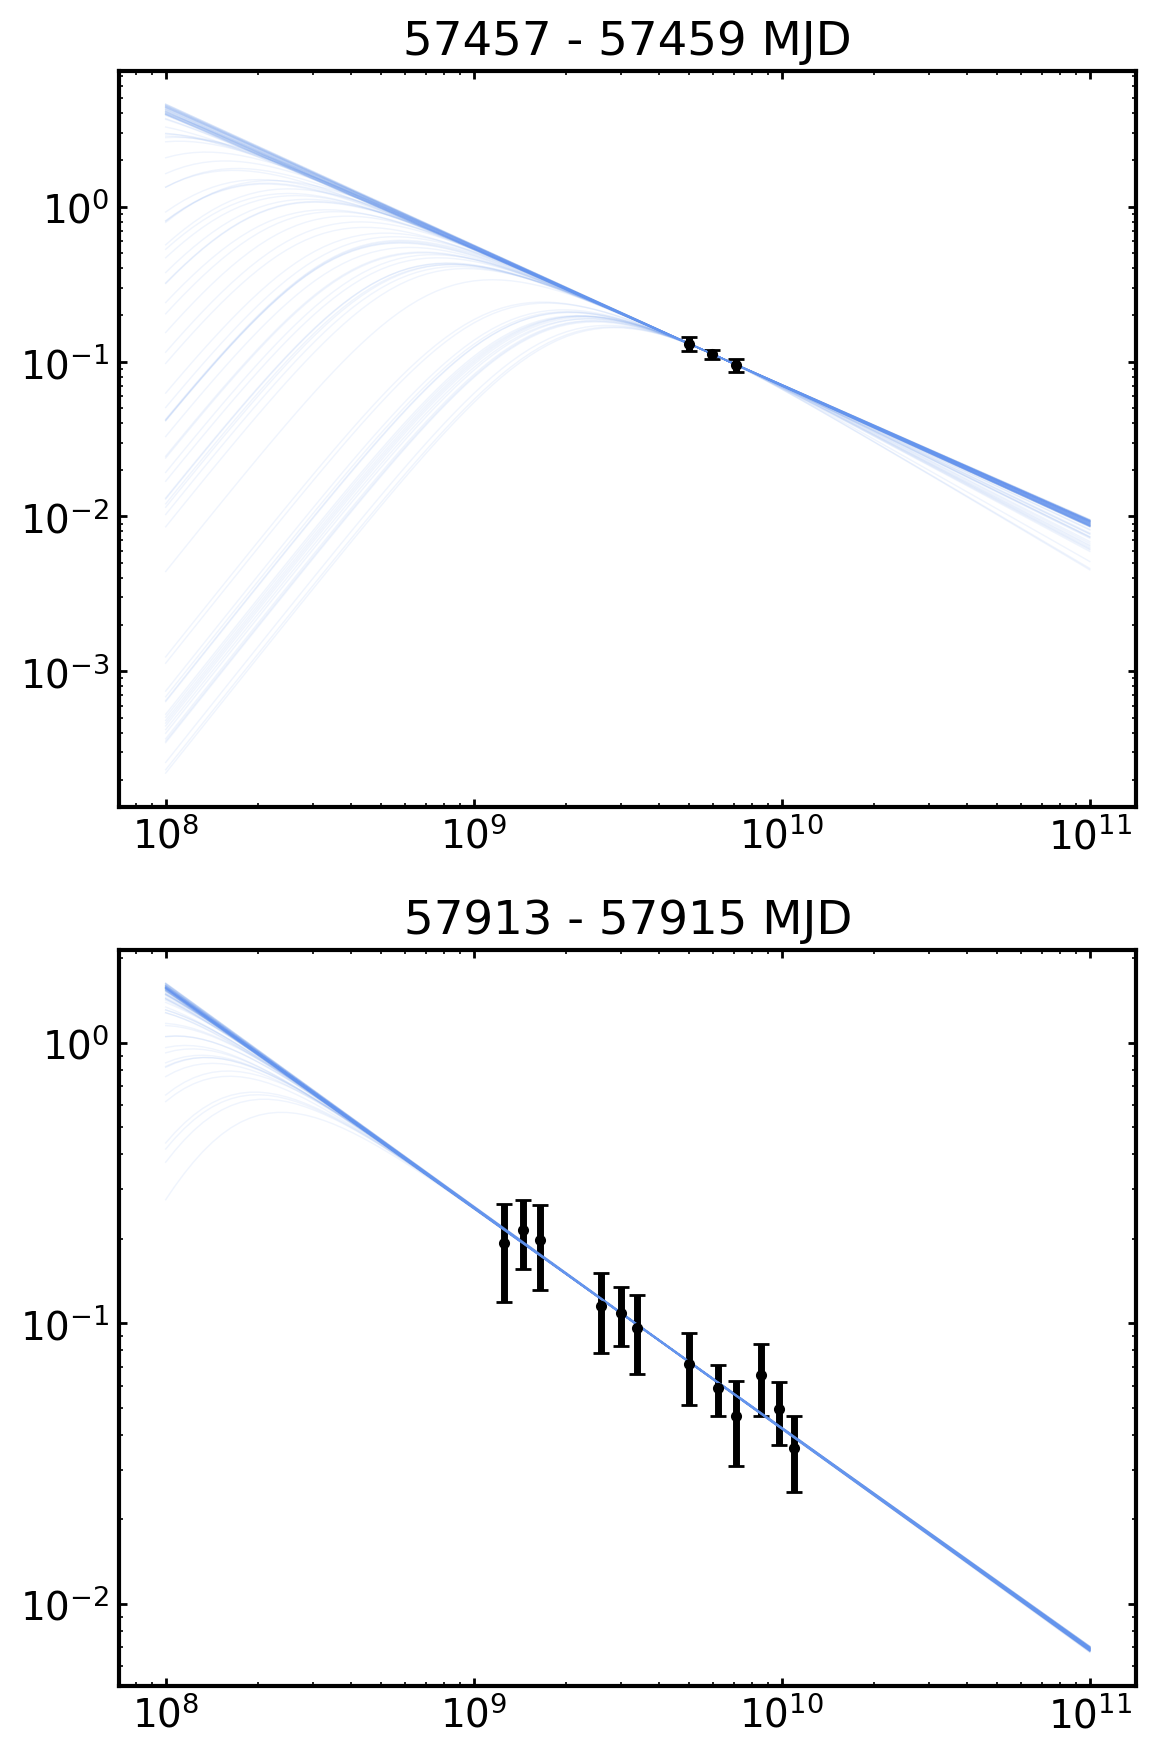

In [42]:
date_ranges = [
    (57457, 57459),
    (57913, 57915)
]

nkeep = 100

results = []

fig, axs = plt.subplots(len(date_ranges),1, figsize=(6,9))
for r, ax in zip(date_ranges, axs):
    data = df[(df.converted_date > r[0]) * (df.converted_date < r[1])]
    print(data)
    ax.errorbar(
        data.converted_freq*1e9, 
        data.converted_flux,
        fmt='o',
        markersize=3,
        yerr=data.converted_flux_err,
        label=f'{r[0]} - {r[1]} MJD',
        uplims=data.upperlimit,
        color='k'
    )
    
    ax.set_yscale("log")
    ax.set_xscale("log")

    # ax.legend();
    ax.set_title(f'{r[0]} - {r[1]} MJD')
    
    try:
        model, sampler = syncfit.do_dynesty(
            F_mJy = data.converted_flux,
            F_error=data.converted_flux_err,
            nu=data.converted_freq,
            model=syncfit.models.B5,
            upperlimits=data.upperlimit
        )
    except RuntimeError:
        continue # this means it couldn't fit it...
    
    results.append((model, sampler))
    
    flat_samples, log_prob = syncfit.analysis.util.extract_output(sampler)

    toplot = flat_samples[-nkeep:]
    nu_plot = np.logspace(8,11,100)
    for val in toplot:
        packed_theta = model.pack_theta(val)
        res = model.SED(nu_plot, **packed_theta)

        ax.plot(nu_plot, res,
                '-', color='cornflowerblue', lw = 0.5, alpha = 0.1)
        
        
fig.savefig("SDSSJ0748-radio-fits.png")

# SDSS J0938

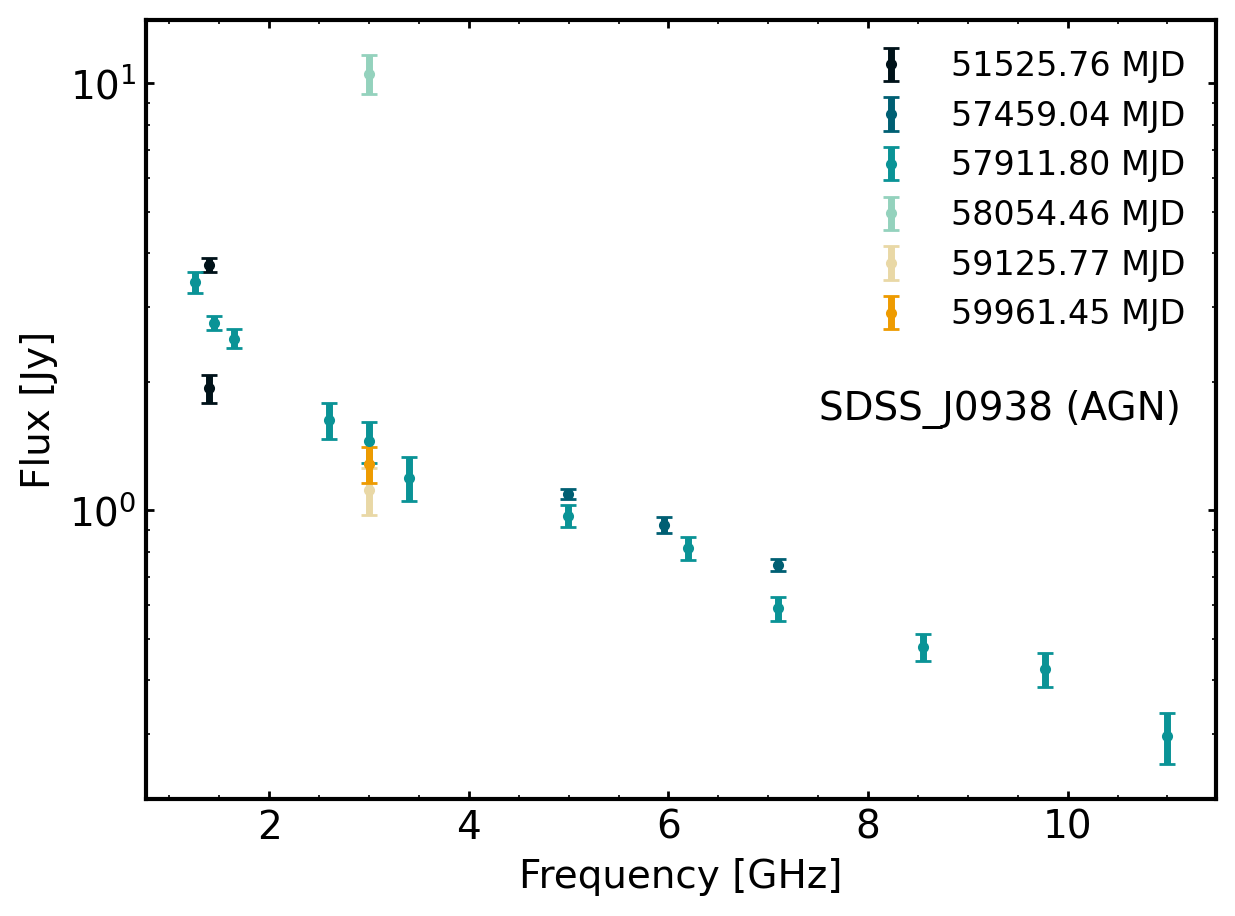

In [43]:
fig, ax = plt.subplots()
df = make_sed("SDSS_J0938", ax=ax)

         name  converted_flux  converted_flux_err  converted_date  \
0  SDSS_J0938          1.0924              0.0283     57459.04178   
2  SDSS_J0938          0.7453              0.0255     57459.04178   
4  SDSS_J0938          0.9261              0.0400     57459.04178   

   converted_wave  converted_freq converted_flux_unit converted_date_unit  \
0    5.997049e+07           4.999                 mJy                 MJD   
2    4.223024e+07           7.099                 mJy                 MJD   
4    5.032608e+07           5.957                 mJy                 MJD   

  converted_wave_unit converted_freq_unit filter_name obs_type upperlimit  \
0                  nm                 GHz           C    radio      False   
2                  nm                 GHz           C    radio      False   
4                  nm                 GHz           C    radio      False   

  reference human_readable_refs telescope  
0   private             private       NaN  
2   private      

9193it [00:31, 152.00it/s, batch: 4 | bound: 2 | nc: 1 | ncall: 61942 | eff(%): 12.255 | loglstar: -3.377 < -2.888 < -2.940 | logz: -8.051 +/-  0.088 | stop:  2.075]                 /home/nfranz/.local/lib/anaconda3/lib/python3.11/site-packages/dynesty/bounding.py:618: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
15586it [01:11, 218.63it/s, batch: 8 | bound: 11 | nc: 1 | ncall: 159757 | eff(%):  9.469 | loglstar: -5.100 < -0.067 < -0.567 | logz: -8.046 +/-  0.068 | stop:  0.897] 


          name  converted_flux  converted_flux_err  converted_date  \
1   SDSS_J0938          0.9706              0.0585     57911.79545   
3   SDSS_J0938          0.5897              0.0379     57911.79545   
5   SDSS_J0938          3.4218              0.1963     57911.79545   
6   SDSS_J0938          2.5266              0.1309     57911.79545   
7   SDSS_J0938          2.7523              0.1067     57911.79545   
8   SDSS_J0938          1.6291              0.1597     57911.79545   
9   SDSS_J0938          1.1919              0.1417     57911.79545   
10  SDSS_J0938          1.4511              0.1579     57911.79545   
11  SDSS_J0938          0.8151              0.0514     57911.79545   
12  SDSS_J0938          0.4793              0.0353     57911.79545   
13  SDSS_J0938          0.2954              0.0404     57911.79545   
14  SDSS_J0938          0.4241              0.0385     57911.79545   

    converted_wave  converted_freq converted_flux_unit converted_date_unit  \
1     5.997

16885it [00:32, 525.14it/s, batch: 8 | bound: 7 | nc: 1 | ncall: 73650 | eff(%): 22.541 | loglstar: -13.824 < -8.407 < -9.334 | logz: -18.741 +/-  0.080 | stop:  0.851]                


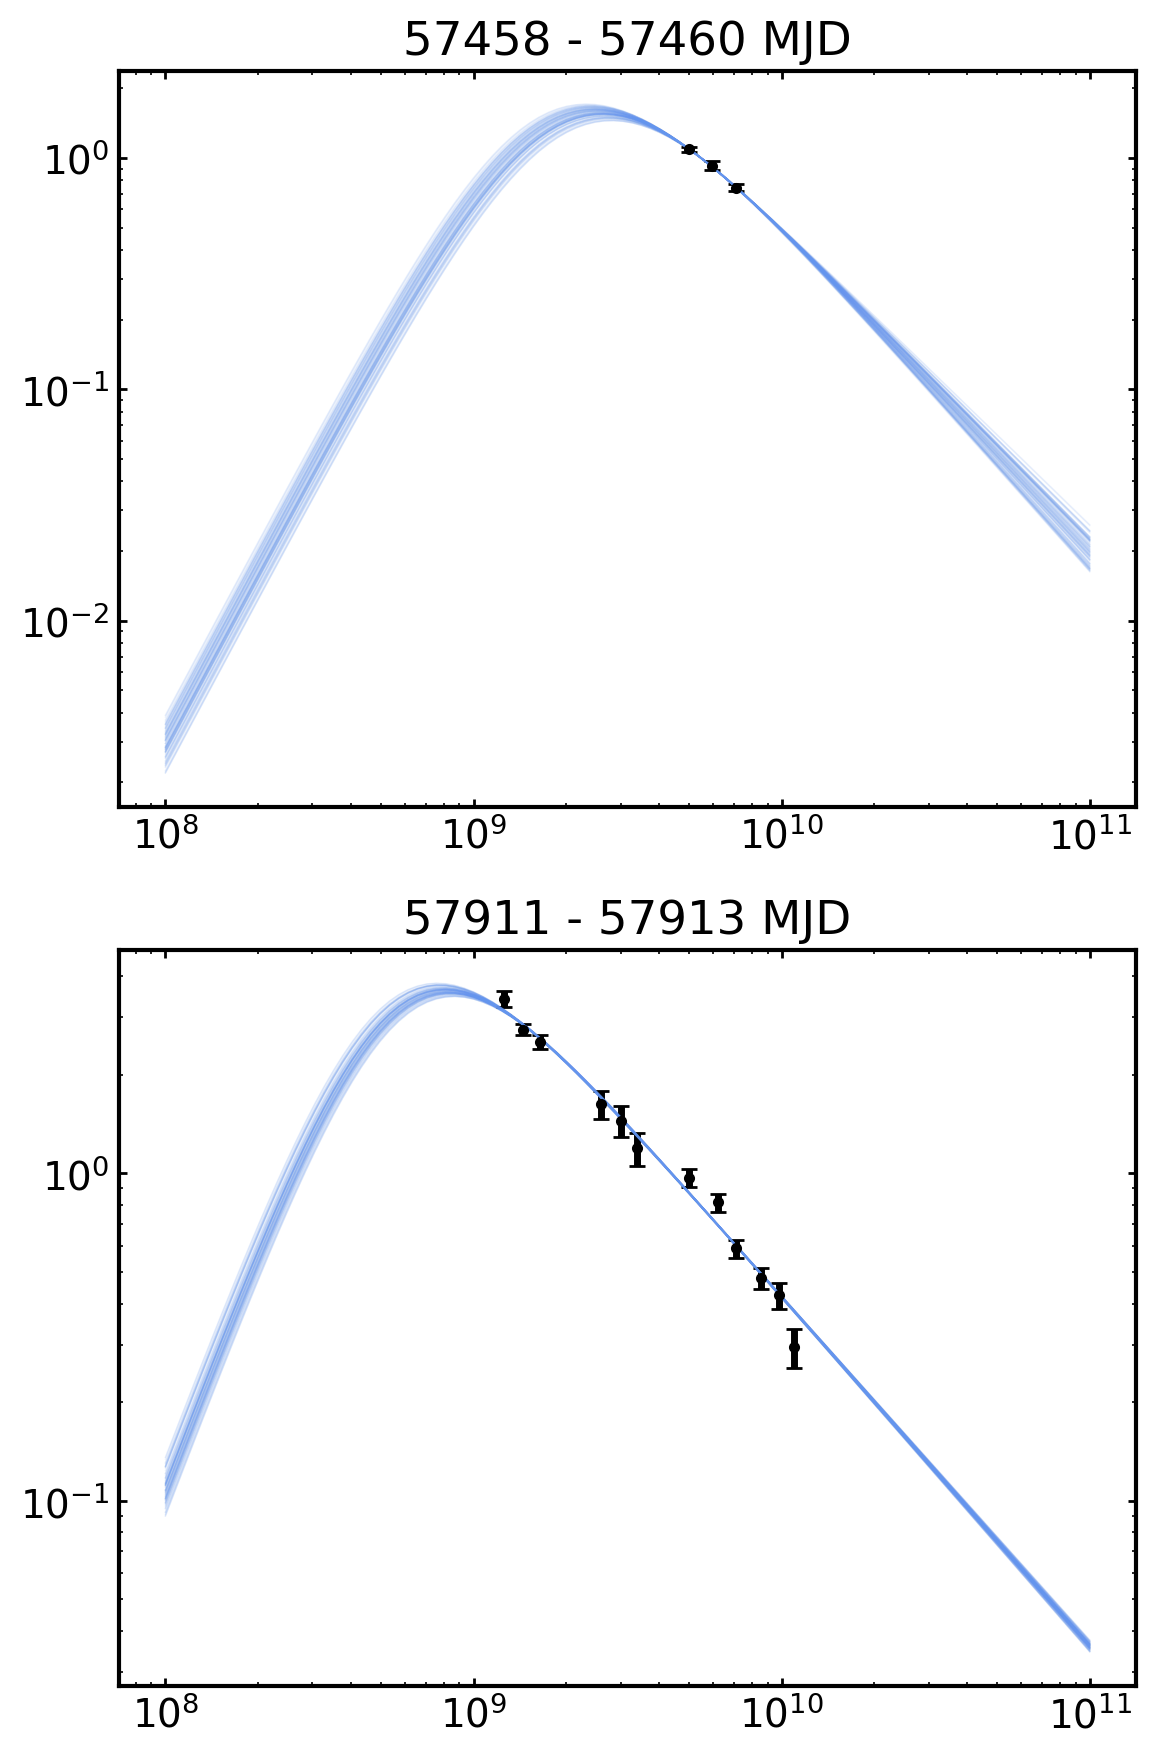

In [44]:
date_ranges = [
    (57458, 57460),
    (57911, 57913)
]

nkeep = 100

results = []

fig, axs = plt.subplots(len(date_ranges),1, figsize=(6,9))
for r, ax in zip(date_ranges, axs):
    data = df[(df.converted_date > r[0]) * (df.converted_date < r[1])]
    print(data)
    ax.errorbar(
        data.converted_freq*1e9, 
        data.converted_flux,
        fmt='o',
        markersize=3,
        yerr=data.converted_flux_err,
        label=f'{r[0]} - {r[1]} MJD',
        uplims=data.upperlimit,
        color='k'
    )
    
    ax.set_yscale("log")
    ax.set_xscale("log")

    # ax.legend();
    ax.set_title(f'{r[0]} - {r[1]} MJD')
    
    try:
        model, sampler = syncfit.do_dynesty(
            F_mJy = data.converted_flux,
            F_error=data.converted_flux_err,
            nu=data.converted_freq,
            model=syncfit.models.B5,
            upperlimits=data.upperlimit
        )
    except RuntimeError:
        continue # this means it couldn't fit it...
    
    results.append((model, sampler))
    
    flat_samples, log_prob = syncfit.analysis.util.extract_output(sampler)

    toplot = flat_samples[-nkeep:]
    nu_plot = np.logspace(8,11,100)
    for val in toplot:
        packed_theta = model.pack_theta(val)
        res = model.SED(nu_plot, **packed_theta)

        ax.plot(nu_plot, res,
                '-', color='cornflowerblue', lw = 0.5, alpha = 0.1)
        
        
fig.savefig("SDSSJ0748-radio-fits.png")